# UNSW-NB15 — Data Preprocessing Pipeline
**Project:** Intrusion Detection using Machine Learning and Explainable AI (XAI)  
**Dataset:** UNSW-NB15  
**Task:** Binary Classification — Normal (0) vs Attack (1)  

---
### Dataset File Overview
| File | Role |
|---|---|
| `UNSW_NB15_training-set.csv` | Official train split 70% |
| `UNSW_NB15_testing-set.csv` | Official test set — **split 50/50 here** to get val + test |
| `UNSW-NB15_1/2/3/4.csv` | Raw full captures (49 cols, no header) — **not used** directly; train/test sets are the curated versions |
| `NUSW-NB15_features.csv` | Feature dictionary — used for documentation |
| `UNSW-NB15_LIST_EVENTS.csv` | Attack event log — reference only |

### Design Principles
- ✅ No data leakage — preprocessing fit **only** on training data
- ✅ Stratified Train / Validation / Test split (70 / 15 / 15)
- ✅ Splits created once with fixed seed, never changed
- ✅ Explicit feature accounting — kept vs removed with reasoning
- ✅ Same fitted transformer reused for val, test, XAI, rule extraction

### Key Dataset Facts
- 49 features in raw files → 44 features in curated sets (after removing IPs, timestamps, raw IDs)
- 3 legitimate categorical features: `proto` (131 unique), `service` (13), `state` (7)
- `attack_cat` = multi-class label → **dropped** (leakage; we use binary `label` only)
- `id` = row identifier → **dropped** (not a network feature)
- `stcpb`, `dtcpb` = TCP base sequence numbers → **dropped** (effectively random identifiers, not generalizable)
- Official test set → split 50/50 to produce val (15%) + test (15%)

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. Imports & Paths

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# ── Reproducibility ────────────────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Paths (Colab-specific, assuming project root 'XAI' in My Drive) ───────────
# Adjust 'XAI' below if your project root folder has a different name.
MY_DRIVE_ROOT = Path('/content/drive/MyDrive/MLmodeling')
PROJECT_ROOT  = MY_DRIVE_ROOT / 'XAI'

DATASET_DIR   = PROJECT_ROOT / 'Datasets' / 'UNSW-NB15' / 'data'
TRAIN_PATH    = DATASET_DIR / 'UNSW_NB15_training-set.csv'
TEST_PATH     = DATASET_DIR / 'UNSW_NB15_testing-set.csv'

SPLITS_DIR    = PROJECT_ROOT / 'splits' / 'UNSW-NB15'
PREPROC_DIR   = SPLITS_DIR # Same as SPLITS_DIR based on original notebook

TARGET_COL   = 'label'

# Create directories if they don't exist
DATASET_DIR.mkdir(parents=True, exist_ok=True)
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
# PREPROC_DIR is the same as SPLITS_DIR, so no need to create it again.

print('Imports complete. Random seed:', RANDOM_STATE)
print('Project root :', PROJECT_ROOT)
print('Dataset dir  :', DATASET_DIR)
print('Train path   :', TRAIN_PATH)
print('Test path    :', TEST_PATH)
print('Splits dir   :', SPLITS_DIR)


Imports complete. Random seed: 42
Project root : /content/drive/MyDrive/MLmodeling/XAI
Dataset dir  : /content/drive/MyDrive/MLmodeling/XAI/Datasets/UNSW-NB15/data
Train path   : /content/drive/MyDrive/MLmodeling/XAI/Datasets/UNSW-NB15/data/UNSW_NB15_training-set.csv
Test path    : /content/drive/MyDrive/MLmodeling/XAI/Datasets/UNSW-NB15/data/UNSW_NB15_testing-set.csv
Splits dir   : /content/drive/MyDrive/MLmodeling/XAI/splits/UNSW-NB15


## 1. Load Raw Data

In [ ]:
df_train_raw = pd.read_csv(TRAIN_PATH)
df_test_raw  = pd.read_csv(TEST_PATH)

print()
print('=== Columns ===')
print(list(df_train_raw.columns))
print()
print('=== Data Types ===')
print(df_train_raw.dtypes.value_counts())
print()
print('=== Label Distribution — Train ===')
print(df_train_raw[TARGET_COL].value_counts())
print()
print('=== Label Distribution — Test (raw, before splitting) ===')
print(df_test_raw[TARGET_COL].value_counts())
print()
print('=== attack_cat (multi-class, train) ===')
print(df_train_raw['attack_cat'].value_counts())


=== Columns ===
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

=== Data Types ===
int64      30
float64    11
object      4
Name: count, dtype: int64

=== Label Distribution — Train ===
label
1    45332
0    37000
Name: count, dtype: int64

=== Label Distribution — Test (raw, before splitting) ===
label
1    119341
0     56000
Name: count, dtype: int64

=== attack_cat (multi-class, train) ===
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
R

## 2. Data Cleaning
### 2.1 Duplicate Detection & Removal

In [ ]:
for name, df in [('Train', df_train_raw), ('Test (raw)', df_test_raw)]:
    n = df.duplicated().sum()
    print(f'  {name}: {n:,} duplicates found')

df_train = df_train_raw.drop_duplicates().reset_index(drop=True)
df_test  = df_test_raw.drop_duplicates().reset_index(drop=True)



  Train: 0 duplicates found
  Test (raw): 0 duplicates found


### 2.2 Missing Value Check

In [ ]:
for name, df in [('Train', df_train), ('Test', df_test)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print(f'  {name}: No missing values.')
    else:
        print(f'  {name}: Missing in {len(missing)} columns:')
        print(missing)

  Train: No missing values.
  Test: No missing values.


### 2.3 Infinite Value Check

In [ ]:
num_cols_raw = df_train.select_dtypes(include=[np.number]).columns.tolist()

for name, df in [('Train', df_train), ('Test', df_test)]:
    inf_cols = [c for c in num_cols_raw if np.isinf(df[c]).any()]
    if not inf_cols:
        print(f'  {name}: No infinite values.')
    else:
        print(f'  {name}: Inf found in {inf_cols} — replacing with NaN')
        df[inf_cols] = df[inf_cols].replace([np.inf, -np.inf], np.nan)

  Train: No infinite values.
  Test: No infinite values.


### 2.4 Constant Feature Removal
Evaluated on training data only — applied to all splits.

In [ ]:
constant_cols = [c for c in num_cols_raw
                 if c not in [TARGET_COL] and df_train[c].nunique() <= 1]

if constant_cols:
    print(f'Constant columns found: {constant_cols}')
    df_train.drop(columns=constant_cols, inplace=True)
    df_test.drop(columns=constant_cols,  inplace=True)
else:
    print('No constant columns found.')

No constant columns found.


## 3. Feature Accounting — Leakage Prevention
Explicit log of every removal decision.

In [ ]:
# ── Features removed with justification ──────────────────────────────────────
#
# 'id'
#   -> Sequential row identifier assigned during dataset curation.
#      Not a network traffic feature. Not available at prediction time.
#      Direct leakage risk if IDs correlate with label order.
#
# 'attack_cat'
#   -> Multi-class attack category label (e.g. 'DoS', 'Exploits', 'Generic').
#      Directly encodes the attack type — severe label leakage.
#      We use binary 'label' (0/1) as the target.
#
# 'stcpb' / 'dtcpb'
#   -> Source and destination TCP base sequence numbers.
#      Effectively random 32-bit integers negotiated per connection.
#      Carry no generalizable signal across connections or machines.
#      High cardinality (39,000+ unique values) with no predictive meaning.
#
# constant_cols (if any, detected above)
#   -> Zero variance — no predictive signal, causes StandardScaler std=0 error.

FEATURES_REMOVED = {
    'id'        : 'Row identifier — not a network feature, not available at prediction time',
    'attack_cat': 'Multi-class attack label — directly encodes the target (label leakage)',
    'stcpb'     : 'TCP base sequence number — random per-connection value, not generalizable (39k+ unique)',
    'dtcpb'     : 'TCP base sequence number — random per-connection value, not generalizable (39k+ unique)',
}
for c in constant_cols:
    FEATURES_REMOVED[c] = 'Constant feature — zero variance, no predictive signal'

cols_to_drop = [c for c in FEATURES_REMOVED if c in df_train.columns]
df_train.drop(columns=cols_to_drop, inplace=True)
df_test.drop(columns=cols_to_drop,  inplace=True)

# Identify feature types on remaining columns
feature_cols         = [c for c in df_train.columns if c != TARGET_COL]
categorical_features = [c for c in feature_cols
                        if df_train[c].dtype == 'object' or str(df_train[c].dtype) == 'str']
numeric_features     = [c for c in feature_cols if c not in categorical_features]

print('=== Feature Accounting Log ===')
print()
print('REMOVED FEATURES:')
for feat, reason in FEATURES_REMOVED.items():
    print(f'  x {feat}: {reason}')
print()
print(f'TARGET             : {TARGET_COL}  (0=Normal, 1=Attack)')
print(f'KEPT — Numeric     : {len(numeric_features)} features')
print(f'KEPT — Categorical : {len(categorical_features)} features -> {categorical_features}')
print()
print('Categorical cardinalities (train):')
for c in categorical_features:
    print(f'  {c}: {df_train[c].nunique()} unique values')

=== Feature Accounting Log ===

REMOVED FEATURES:
  x id: Row identifier — not a network feature, not available at prediction time
  x attack_cat: Multi-class attack label — directly encodes the target (label leakage)
  x stcpb: TCP base sequence number — random per-connection value, not generalizable (39k+ unique)
  x dtcpb: TCP base sequence number — random per-connection value, not generalizable (39k+ unique)

TARGET             : label  (0=Normal, 1=Attack)
KEPT — Numeric     : 37 features
KEPT — Categorical : 3 features -> ['proto', 'service', 'state']

Categorical cardinalities (train):
  proto: 131 unique values
  service: 13 unique values
  state: 7 unique values


## 4. Label Check
Binary label `label` is already encoded as 0/1. No engineering needed.

=== Binary Label Distribution ===
  Train        -> Normal:  37,000 (44.9%) | Attack:  45,332 (55.1%) | Ratio: 1.23x
  Test (raw)   -> Normal:  56,000 (31.9%) | Attack: 119,341 (68.1%) | Ratio: 2.13x


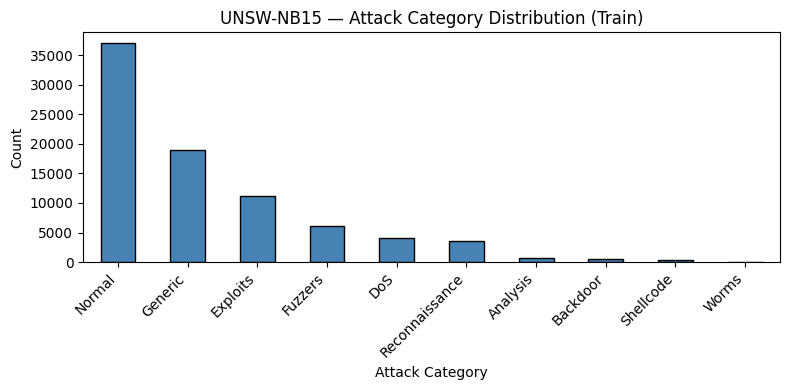


Note: Mild class imbalance. F1, F2, ROC-AUC, PR-AUC are primary metrics


In [ ]:
print('=== Binary Label Distribution ===')
for name, df in [('Train', df_train), ('Test (raw)', df_test)]:
    vc    = df[TARGET_COL].value_counts().sort_index()
    total = len(df)
    n0    = vc.get(0, 0)
    n1    = vc.get(1, 0)
    ratio = n1 / n0 if n0 > 0 else float('inf')
    print(f'  {name:12s} -> Normal: {n0:>7,} ({n0/total*100:.1f}%) | Attack: {n1:>7,} ({n1/total*100:.1f}%) | Ratio: {ratio:.2f}x')

# Class distribution plot
fig, ax = plt.subplots(figsize=(8, 4))
attack_cats = df_train_raw['attack_cat'].value_counts()
attack_cats.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('UNSW-NB15 — Attack Category Distribution (Train)')
ax.set_xlabel('Attack Category')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(DATASET_DIR / 'class_distribution.png', dpi=150)
plt.show()
print()
print('Note: Mild class imbalance. F1, F2, ROC-AUC, PR-AUC are primary metrics')

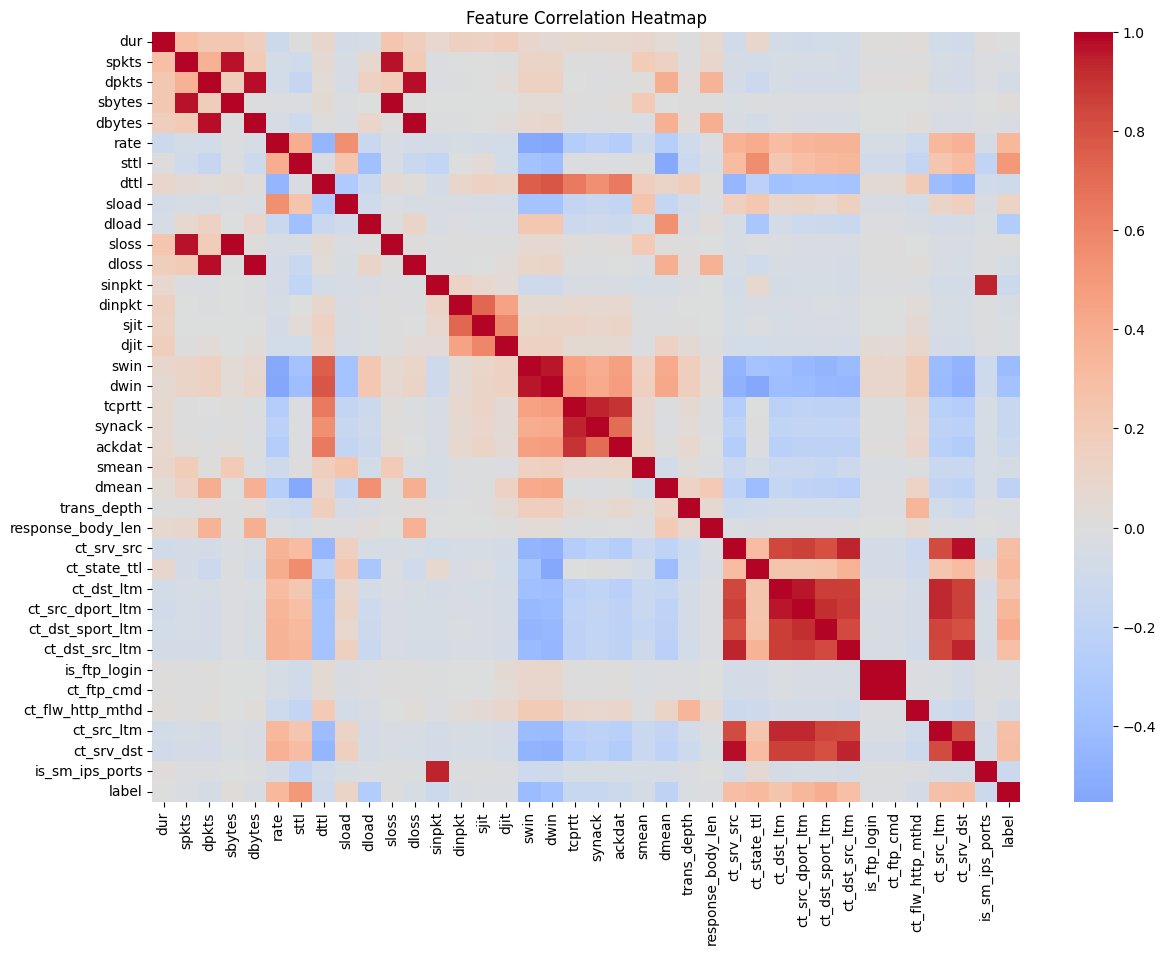

In [ ]:
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
numeric_df = df_train.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.show()

## 5. Train / Validation / Test Split
To achieve the required **70 / 15 / 15** split, the official test set is split 50/50 into val and test.  
The training set is kept as-is (it is the official train partition).  
All splits are stratified on the binary label. Created once, never changed.

In [ ]:
df_all = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)

X_all = df_all.drop(columns=[TARGET_COL]).reset_index(drop=True)
y_all = df_all[TARGET_COL].reset_index(drop=True)

# True overall split: 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all,
    test_size=0.30,
    stratify=y_all,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)
X_val  = X_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_val  = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

total = len(X_train) + len(X_val) + len(X_test)
print('=== Split Sizes ===')
print(f'  Train      : {len(X_train):>7,} rows ({len(X_train)/total*100:.1f}%)')
print(f'  Validation : {len(X_val):>7,} rows ({len(X_val)/total*100:.1f}%)')
print(f'  Test       : {len(X_test):>7,} rows ({len(X_test)/total*100:.1f}%)')
print(f'  Total      : {total:>7,}')
print()
print('=== Stratification Check ===')
for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    pct = y.value_counts(normalize=True).sort_index()
    print(f'  {name:5s} -> Normal: {pct.get(0,0)*100:.2f}% | Attack: {pct.get(1,0)*100:.2f}%')

=== Split Sizes ===
  Train      : 180,371 rows (70.0%)
  Validation :  38,651 rows (15.0%)
  Test       :  38,651 rows (15.0%)
  Total      : 257,673

=== Stratification Check ===
  Train -> Normal: 36.09% | Attack: 63.91%
  Val   -> Normal: 36.09% | Attack: 63.91%
  Test  -> Normal: 36.09% | Attack: 63.91%


## 6. Preprocessing Pipeline
**Fit only on `X_train`. The same fitted transformer is applied to val, test, XAI, and rule extraction.**

- **Numeric** (37 features) → median impute → StandardScaler  
- **Categorical** (`proto`=131 unique, `service`=13, `state`=7) → most_frequent impute → OneHotEncoder(handle_unknown='ignore')

> `proto` has 131 unique values in train; test has 2 additional values (`icmp`, `rtp`).  
> `handle_unknown='ignore'` ensures unseen values are safely encoded as all-zeros.

In [ ]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline,     numeric_features),
    ('cat', categorical_pipeline, categorical_features),
], remainder='drop')   # no accidental column passthrough

# ── FIT on training data ONLY ─────────────────────────────────────────────────
preprocessor.fit(X_train)
print('Preprocessor fitted on X_train only.')

# ── TRANSFORM all splits with the same fitted preprocessor ───────────────────
X_train_proc = preprocessor.transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

print(f'\nProcessed shapes:')
print(f'  X_train : {X_train_proc.shape}')
print(f'  X_val   : {X_val_proc.shape}')
print(f'  X_test  : {X_test_proc.shape}')

Preprocessor fitted on X_train only.

Processed shapes:
  X_train : (180371, 192)
  X_val   : (38651, 192)
  X_test  : (38651, 192)


## 7. Reconstruct Feature Names
Named features required for SHAP, LIME, and rule extraction.

In [ ]:
ohe_feature_names = list(
    preprocessor.named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categorical_features)
)
feature_names_out = numeric_features + ohe_feature_names

print(f'Total features after preprocessing : {len(feature_names_out)}')
print(f'  Numeric    : {len(numeric_features)}')
print(f'  OHE output : {len(ohe_feature_names)}  (from {len(categorical_features)} categorical cols)')
print(f'  OHE breakdown:')
for c in categorical_features:
    n = df_train[c].nunique()
    print(f'    {c}: {n} categories -> {n} OHE cols')

# Convert to named DataFrames
X_train_df = pd.DataFrame(X_train_proc, columns=feature_names_out)
X_val_df   = pd.DataFrame(X_val_proc,   columns=feature_names_out)
X_test_df  = pd.DataFrame(X_test_proc,  columns=feature_names_out)

X_train_df.head(3)

Total features after preprocessing : 192
  Numeric    : 37
  OHE output : 155  (from 3 categorical cols)
  OHE breakdown:
    proto: 131 categories -> 131 OHE cols
    service: 13 categories -> 13 OHE cols
    state: 7 categories -> 7 OHE cols


,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,...,service_ssl,state_ACC,state_CON,state_ECO,state_FIN,state_INT,state_REQ,state_RST,state_URN,state_no
0,-0.208891,-0.130884,-0.144617,-0.048454,-0.095148,-0.550276,-1.454147,-0.495350,-0.374175,-0.011316,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.209062,-0.130884,-0.162087,-0.048050,-0.096231,0.211753,0.721901,-0.752438,0.157703,-0.272643,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-0.203045,0.237738,0.309614,-0.030853,0.165046,-0.550291,-1.454147,-0.495350,-0.373174,3.259746,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


## 8. Sanity Checks

In [ ]:
print('=== Check 1: No NaN in processed arrays ===')
for name, arr in [('train', X_train_proc), ('val', X_val_proc), ('test', X_test_proc)]:
    n = np.isnan(arr).sum()
    print(f'  {name}: {"clean" if n == 0 else f"{n} NaNs found"}')

print()
print('=== Check 2: No Inf in processed arrays ===')
for name, arr in [('train', X_train_proc), ('val', X_val_proc), ('test', X_test_proc)]:
    n = np.isinf(arr).sum()
    print(f'  {name}: {"clean" if n == 0 else f"{n} Infs found"}')

print()
print('=== Check 3: Feature count consistency ===')
shapes = [X_train_proc.shape[1], X_val_proc.shape[1], X_test_proc.shape[1]]
print(f'  train={shapes[0]}, val={shapes[1]}, test={shapes[2]}')
print(f'  Consistent: {"YES" if len(set(shapes)) == 1 else "MISMATCH — check pipeline"}')

print()
print('=== Check 4: Row count matches labels ===')
for name, arr, y in [('train', X_train_proc, y_train),
                     ('val',   X_val_proc,   y_val),
                     ('test',  X_test_proc,  y_test)]:
    match = arr.shape[0] == len(y)
    print(f'  {name}: X={arr.shape[0]:,}, y={len(y):,} -> {"OK" if match else "MISMATCH"}')

print()
print('=== Check 5: Train means ~ 0 (StandardScaler applied correctly) ===')
for feat, val in X_train_df[numeric_features[:5]].mean().round(6).items():
    print(f'  {feat}: {val}')

print()
print('=== Check 6: Unseen proto values handled by handle_unknown=ignore ===')
train_proto = set(df_train['proto'].unique())
test_proto  = set(df_test_raw['proto'].unique())
unseen      = test_proto - train_proto
print(f'  Proto values in test not seen in train: {unseen}')
print(f'  These are encoded as all-zeros (safe — no error raised)')

=== Check 1: No NaN in processed arrays ===
  train: clean
  val: clean
  test: clean

=== Check 2: No Inf in processed arrays ===
  train: clean
  val: clean
  test: clean

=== Check 3: Feature count consistency ===
  train=192, val=192, test=192
  Consistent: YES

=== Check 4: Row count matches labels ===
  train: X=180,371, y=180,371 -> OK
  val: X=38,651, y=38,651 -> OK
  test: X=38,651, y=38,651 -> OK

=== Check 5: Train means ~ 0 (StandardScaler applied correctly) ===
  dur: -0.0
  spkts: -0.0
  dpkts: 0.0
  sbytes: -0.0
  dbytes: 0.0

=== Check 6: Unseen proto values handled by handle_unknown=ignore ===
  Proto values in test not seen in train: {'rtp', 'icmp'}
  These are encoded as all-zeros (safe — no error raised)


## 9. Save All Outputs

In [ ]:
# ── Processed feature splits ──────────────────────────────────────────────────
X_train_df.to_csv(SPLITS_DIR / 'X_train.csv', index=False)
X_val_df.to_csv(  SPLITS_DIR / 'X_val.csv',   index=False)
X_test_df.to_csv( SPLITS_DIR / 'X_test.csv',  index=False)

# ── Labels ────────────────────────────────────────────────────────────────────
y_train.to_csv(SPLITS_DIR / 'y_train.csv', index=False)
y_val.to_csv(  SPLITS_DIR / 'y_val.csv',   index=False)
y_test.to_csv( SPLITS_DIR / 'y_test.csv',  index=False)

# ── Fitted preprocessor ───────────────────────────────────────────────────────
joblib.dump(preprocessor, PREPROC_DIR / 'preprocessor.joblib')

# ── Feature names (for SHAP / LIME) ──────────────────────────────────────────
pd.Series(feature_names_out).to_csv(
    PREPROC_DIR / 'feature_names.csv', index=False, header=False
)

# ── Metadata / reproducibility record ────────────────────────────────────────
meta = {
    'dataset'              : 'UNSW-NB15',
    'train_raw_shape'      : list(df_train_raw.shape),
    'test_raw_shape'       : list(df_test_raw.shape),
    'train_clean_size'     : int(len(X_train)),
    'val_size'             : int(len(X_val)),
    'test_size'            : int(len(X_test)),
    'n_features_input'     : len(feature_cols),
    'n_features_after_ohe' : len(feature_names_out),
    'numeric_features'     : numeric_features,
    'categorical_features' : categorical_features,
    'ohe_features'         : ohe_feature_names,
    'removed_features'     : FEATURES_REMOVED,
    'random_state'         : RANDOM_STATE,
    'split_strategy'       : 'Official train kept; official test split 50/50 -> val+test',
    'split_ratios_approx'  : f'{len(X_train)/total*100:.1f}/{len(X_val)/total*100:.1f}/{len(X_test)/total*100:.1f}',
    'stratified'           : True,
    'label_map'            : {'0': 'Normal', '1': 'Attack'},
    'unseen_proto_in_test' : list(test_proto - train_proto),
}
with open(DATASET_DIR / 'preprocessing_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('=== All outputs saved ===')
print(f'  {SPLITS_DIR}\\X_train.csv')
print(f'  {SPLITS_DIR}\\X_val.csv')
print(f'  {SPLITS_DIR}\\X_test.csv')
print(f'  {SPLITS_DIR}\\y_train.csv')
print(f'  {SPLITS_DIR}\\y_val.csv')
print(f'  {SPLITS_DIR}\\y_test.csv')
print(f'  {SPLITS_DIR}\\preprocessor.joblib')
print(f'  {SPLITS_DIR}\\feature_names.csv')
print(f'  {DATASET_DIR}\\preprocessing_metadata.json')

=== All outputs saved ===
  /content/drive/MyDrive/MLmodeling/XAI/splits/UNSW-NB15\X_train.csv
  /content/drive/MyDrive/MLmodeling/XAI/splits/UNSW-NB15\X_val.csv
  /content/drive/MyDrive/MLmodeling/XAI/splits/UNSW-NB15\X_test.csv
  /content/drive/MyDrive/MLmodeling/XAI/splits/UNSW-NB15\y_train.csv
  /content/drive/MyDrive/MLmodeling/XAI/splits/UNSW-NB15\y_val.csv
  /content/drive/MyDrive/MLmodeling/XAI/splits/UNSW-NB15\y_test.csv
  /content/drive/MyDrive/MLmodeling/XAI/splits/UNSW-NB15\preprocessor.joblib
  /content/drive/MyDrive/MLmodeling/XAI/splits/UNSW-NB15\feature_names.csv
  /content/drive/MyDrive/MLmodeling/XAI/Datasets/UNSW-NB15/data\preprocessing_metadata.json


## 10. Preprocessing Summary

In [ ]:
print('=' * 62)
print('        UNSW-NB15 — PREPROCESSING SUMMARY')
print('=' * 62)

print(f'  After dedup + split    :')
print(f'    Train                : {len(X_train):,}  ({len(X_train)/total*100:.1f}%)')
print(f'    Val                  : {len(X_val):,}  ({len(X_val)/total*100:.1f}%)')
print(f'    Test                 : {len(X_test):,}  ({len(X_test)/total*100:.1f}%)')
print(f'  Missing values         : 0 (confirmed)')
print(f'  Infinite values        : 0 (confirmed)')
print(f'  Removed features       : {list(FEATURES_REMOVED.keys())}')
print(f'  Input features         : {len(feature_cols)}')
print(f'  After OHE              : {len(feature_names_out)}')
print(f'    Numeric              : {len(numeric_features)}')
print(f'    OHE output           : {len(ohe_feature_names)}')
print(f'  Unseen proto in test   : {list(test_proto - train_proto)} (handled by ignore)')
print()
print('  LEAKAGE PREVENTION:')
print('    Preprocessor fit on X_train only')
print('    attack_cat (multi-class label) removed')
print('    id, stcpb, dtcpb removed')
print('    Val/Test never seen during fitting')
print()
print('  DOWNSTREAM USAGE (modelling notebook):')
print('    -> Load splits/preprocessor.joblib')
print('    -> Wrap as Pipeline([preprocessor, model]).fit(X_train_raw, y_train)')
print('    -> Use processed CSVs + feature_names.csv for SHAP/LIME')
print('=' * 62)

        UNSW-NB15 — PREPROCESSING SUMMARY
  After dedup + split    :
    Train                : 180,371  (70.0%)
    Val                  : 38,651  (15.0%)
    Test                 : 38,651  (15.0%)
  Missing values         : 0 (confirmed)
  Infinite values        : 0 (confirmed)
  Removed features       : ['id', 'attack_cat', 'stcpb', 'dtcpb']
  Input features         : 40
  After OHE              : 192
    Numeric              : 37
    OHE output           : 155
  Unseen proto in test   : ['rtp', 'icmp'] (handled by ignore)

  LEAKAGE PREVENTION:
    Preprocessor fit on X_train only
    attack_cat (multi-class label) removed
    id, stcpb, dtcpb removed
    Val/Test never seen during fitting

  DOWNSTREAM USAGE (modelling notebook):
    -> Load splits/preprocessor.joblib
    -> Wrap as Pipeline([preprocessor, model]).fit(X_train_raw, y_train)
    -> Use processed CSVs + feature_names.csv for SHAP/LIME


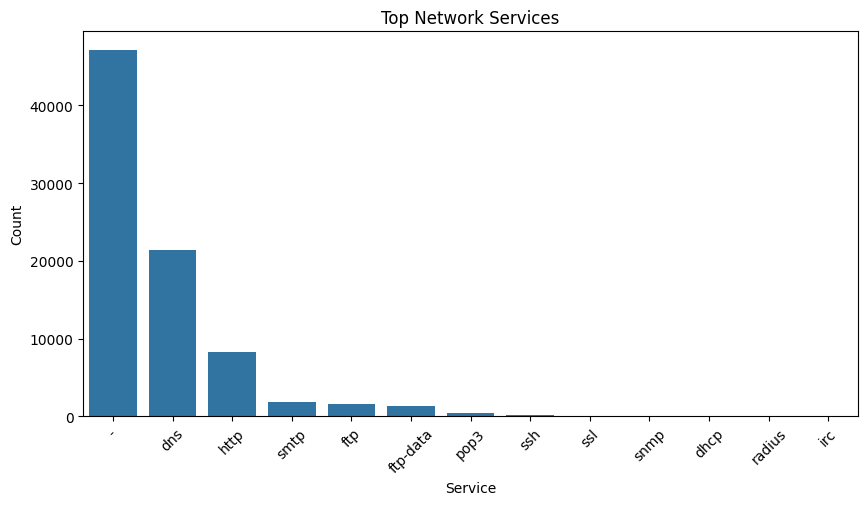

service
-           47153
dns         21367
http         8287
smtp         1851
ftp          1552
ftp-data     1396
pop3          423
ssh           204
ssl            30
snmp           29
dhcp           26
radius          9
irc             5
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_train,
    x="service",
    order=df_train["service"].value_counts().head(15).index
)

plt.title("Top Network Services")
plt.xlabel("Service")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

print(df_train["service"].value_counts().head(15))

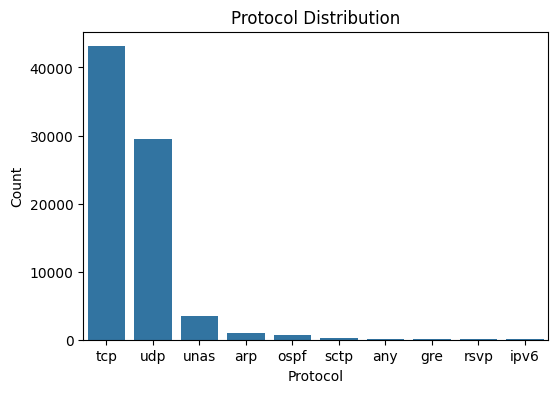

proto
tcp       43095
udp       29418
unas       3515
arp         987
ospf        676
sctp        324
any          96
gre          88
rsvp         64
ipv6         61
sep          58
sun-nd       54
swipe        52
mobile       52
pim          52
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df_train,
    x="proto",
    order=df_train["proto"].value_counts().head(10).index
)

plt.title("Protocol Distribution")
plt.xlabel("Protocol")
plt.ylabel("Count")

plt.show()

print(df_train["proto"].value_counts().head(15))

---
## Preprocessing Complete
